# Tweedie Regression Models - Loss Cost Prediction
## Handling Zero-Inflated Insurance Claims with Tweedie Distribution

**Author:** Nandeesh H S  
**Project:** Insurance Risk Analytics & Claims Prediction

---

### Objectives
1. Train XGBoost Tweedie regressor with Optuna
2. Train LightGBM Tweedie regressor with Optuna
3. Train GLM Tweedie regressor baseline
4. Create weighted ensemble for LC and HALC
5. Evaluate regression performance (MSE, RMSE, MAE)

In [1]:
# Import libraries
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path('..').resolve() / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from data_loader import DataLoader, create_target_variables
from feature_engineer import FeatureEngineer
from preprocessor import DataPreprocessor
from models.regressor import TweedieRegressionModel
from evaluation import ModelEvaluator
from visualization import InsuranceVisualizer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


C:\Users\Nandeesh H S\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preparation

In [2]:
# Load and prepare data
loader = DataLoader()
train_df, test_df = loader.load_data()
train_df = create_target_variables(train_df)

# Feature engineering
engineer = FeatureEngineer()
train_fe = engineer.engineer_features(train_df, is_train=True)
test_fe = engineer.engineer_features(test_df, is_train=False)

# Preprocessing
preprocessor = DataPreprocessor()
X_train, X_test, targets = preprocessor.fit_transform(
    train_fe, test_fe,
    target_for_selection=train_fe['CS'].values if 'CS' in train_fe.columns else None,
    apply_feature_selection=True
)

y_lc = targets['LC']
y_halc = targets['HALC']

print(f"\nData prepared for regression:")
print(f"  Features: {X_train.shape[1]}")
print(f"  Training samples: {len(X_train):,}")
print(f"\nTarget Statistics:")
print(f"  LC mean: {y_lc.mean():.2f}")
print(f"  LC zeros: {(y_lc==0).sum():,} ({(y_lc==0).mean()*100:.1f}%)")
print(f"  HALC mean: {y_halc.mean():.2f}")
print(f"  HALC zeros: {(y_halc==0).sum():,} ({(y_halc==0).mean()*100:.1f}%)")

INFO:data_loader:Loading datasets...


INFO:data_loader:Training data loaded: (37451, 28)


INFO:data_loader:Test data loaded: (15787, 23)


INFO:data_loader:Validating data quality...


INFO:data_loader:Data validation complete


INFO:data_loader:Target variables created successfully


INFO:data_loader:Claim rate: 11.08%


Starting feature engineering for train data...
Feature engineering complete. New shape: (37451, 35)
Starting feature engineering for test data...


Feature engineering complete. New shape: (15787, 27)

DATA PREPROCESSING PIPELINE

Initial features: 27
Encoding 6 categorical variables...
Features after encoding: 29
Scaling features...
Selecting features using rf_importance...


Selected 15 features
Final features after selection: 15

Preprocessing complete!

Data prepared for regression:
  Features: 15
  Training samples: 37,451

Target Statistics:
  LC mean: 69.81
  LC zeros: 33,300 (88.9%)
  HALC mean: 128.15
  HALC zeros: 33,317 (89.0%)


## 2. Understanding Tweedie Distribution

### Why Tweedie for Insurance Claims?

The **Tweedie distribution** is ideal for insurance claims because:
1. **Handles zeros naturally** - Mass at zero for "no claim" cases
2. **Continuous positive values** - For actual claim amounts
3. **Compound Poisson-Gamma** - Models frequency × severity

**Variance Power Parameter (p)**:
- p = 0: Normal distribution
- p = 1: Poisson distribution
- **p ∈ (1, 2): Compound Poisson-Gamma** ✓ (Insurance claims)
- p = 2: Gamma distribution
- p = 3: Inverse Gaussian

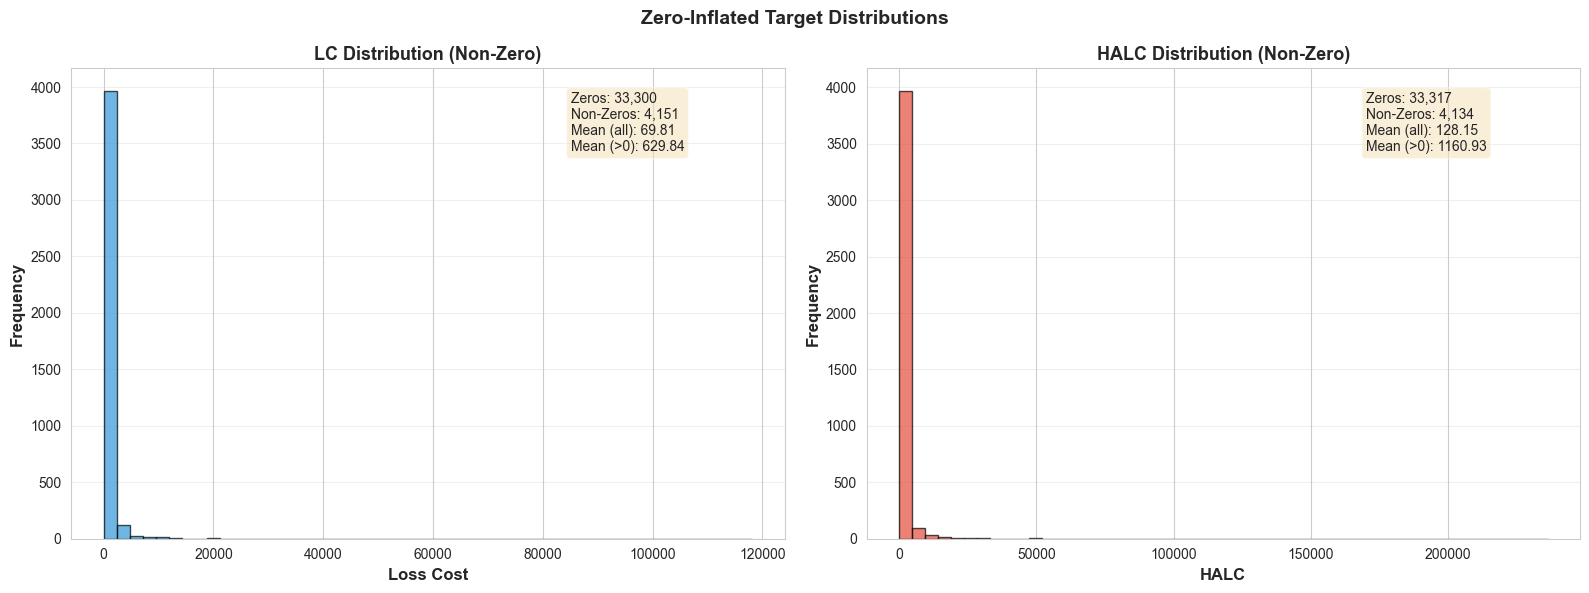


[INSIGHT] ~89% zeros + right-skewed continuous values = Perfect Tweedie case!


In [3]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LC distribution
lc_nonzero = y_lc[y_lc > 0]
axes[0].hist(lc_nonzero, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Loss Cost', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('LC Distribution (Non-Zero)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add statistics
stats_text = f"Zeros: {(y_lc==0).sum():,}\nNon-Zeros: {(y_lc>0).sum():,}\nMean (all): {y_lc.mean():.2f}\nMean (>0): {lc_nonzero.mean():.2f}"
axes[0].text(0.70, 0.95, stats_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# HALC distribution
halc_nonzero = y_halc[y_halc > 0]
axes[1].hist(halc_nonzero, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('HALC', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('HALC Distribution (Non-Zero)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add statistics
stats_text = f"Zeros: {(y_halc==0).sum():,}\nNon-Zeros: {(y_halc>0).sum():,}\nMean (all): {y_halc.mean():.2f}\nMean (>0): {halc_nonzero.mean():.2f}"
axes[1].text(0.70, 0.95, stats_text,
            transform=axes[1].transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Zero-Inflated Target Distributions', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n[INSIGHT] ~89% zeros + right-skewed continuous values = Perfect Tweedie case!")

## 3. Train Tweedie Regression Models

### 3.1 XGBoost Tweedie with Optuna

In [4]:
# Initialize Tweedie regressor
regressor = TweedieRegressionModel()

# Train XGBoost for LC
xgb_lc_model, xgb_lc_mse = regressor.train_xgboost_lc(X_train, y_lc, n_trials=5)

print(f"\nXGBoost Tweedie LC Training Complete!")
print(f"  Best MSE: {xgb_lc_mse:.2f}")


Training XGBoost Tweedie for LC...


  0%|          | 0/5 [00:00<?, ?it/s]

Best trial: 0. Best value: 22711.4:   0%|          | 0/5 [00:02<?, ?it/s]

Best trial: 0. Best value: 22711.4:  20%|██        | 1/5 [00:02<00:08,  2.10s/it]

Best trial: 0. Best value: 22711.4:  20%|██        | 1/5 [00:04<00:08,  2.10s/it]

...

Best trial: 0. Best value: 22711.4:  80%|████████  | 4/5 [00:06<00:01,  1.59s/it]

Best trial: 4. Best value: 1456.41:  80%|████████  | 4/5 [00:08<00:01,  1.59s/it]

Best trial: 4. Best value: 1456.41: 100%|██████████| 5/5 [00:08<00:00,  1.74s/it]

Best trial: 4. Best value: 1456.41: 100%|██████████| 5/5 [00:08<00:00,  1.78s/it]

XGBoost LC - Best MSE: 1456.41

XGBoost Tweedie LC Training Complete!
  Best MSE: 1456.41


### 3.2 LightGBM Tweedie with Optuna

In [5]:
# Train LightGBM for LC
lgb_lc_model, lgb_lc_mse = regressor.train_lightgbm_lc(X_train, y_lc, n_trials=5)

print(f"\nLightGBM Tweedie LC Training Complete!")
print(f"  Best MSE: {lgb_lc_mse:.2f}")


Training LightGBM Tweedie for LC...


  0%|          | 0/5 [00:00<?, ?it/s]

Best trial: 0. Best value: 334162:   0%|          | 0/5 [00:00<?, ?it/s]

Best trial: 0. Best value: 334162:  20%|██        | 1/5 [00:00<00:02,  1.63it/s]

Best trial: 0. Best value: 334162:  20%|██        | 1/5 [00:00<00:02,  1.63it/s]

...

Best trial: 0. Best value: 334162:  80%|████████  | 4/5 [00:01<00:00,  2.85it/s]

Best trial: 0. Best value: 334162:  80%|████████  | 4/5 [00:01<00:00,  2.85it/s]

Best trial: 0. Best value: 334162: 100%|██████████| 5/5 [00:01<00:00,  2.95it/s]

Best trial: 0. Best value: 334162: 100%|██████████| 5/5 [00:01<00:00,  2.63it/s]

LightGBM LC - Best MSE: 334161.94

LightGBM Tweedie LC Training Complete!
  Best MSE: 334161.94


### 3.3 GLM Tweedie Baseline

In [6]:
# Train GLM for LC
glm_lc_model, glm_lc_mse = regressor.train_glm_lc(X_train, y_lc)

print(f"\nGLM Tweedie LC Training Complete!")
print(f"  MSE: {glm_lc_mse:.2f}")


Training GLM Tweedie for LC...
GLM LC - MSE: 702009.11

GLM Tweedie LC Training Complete!
  MSE: 702009.11


## 4. Model Comparison


Model Performance Comparison (LC):
           Model      MSE (LC)
 XGBoost Tweedie   1456.408341
LightGBM Tweedie 334161.935202
     GLM Tweedie 702009.108923


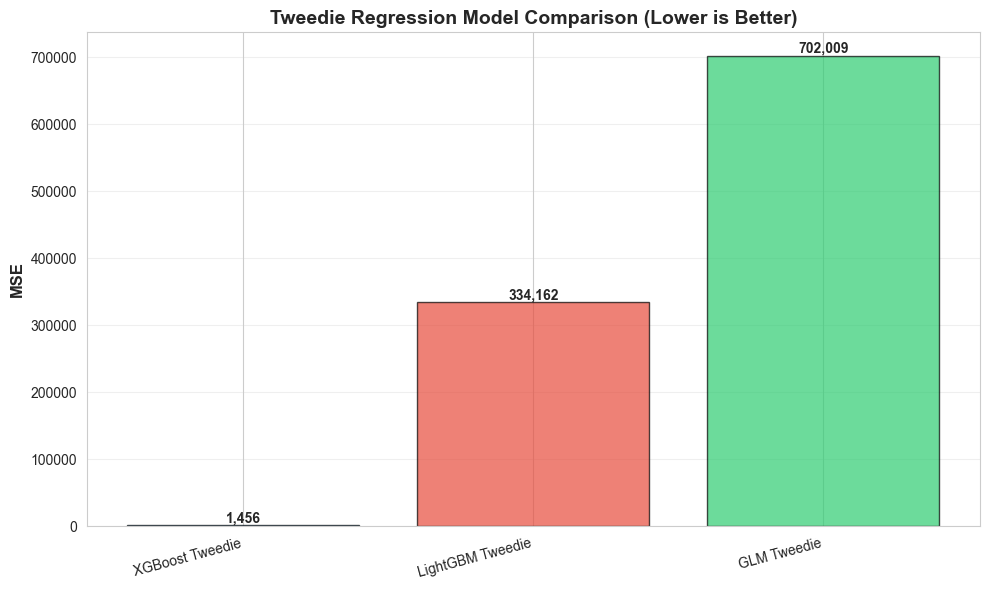

In [7]:
# Compare models
models_comparison = pd.DataFrame({
    'Model': ['XGBoost Tweedie', 'LightGBM Tweedie', 'GLM Tweedie'],
    'MSE (LC)': [xgb_lc_mse, lgb_lc_mse, glm_lc_mse]
}).sort_values('MSE (LC)')

print("\nModel Performance Comparison (LC):")
print(models_comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(models_comparison['Model'], models_comparison['MSE (LC)'], 
              color=colors, edgecolor='black', alpha=0.7)

ax.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax.set_title('Tweedie Regression Model Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 5. Train HALC Models and Create Ensemble

In [8]:
# Calculate LC ensemble weights (inverse MSE = better model gets higher weight)
import numpy as np
lc_scores = np.array([xgb_lc_mse, lgb_lc_mse, glm_lc_mse])
regressor.lc_weights = (1.0 / lc_scores) / (1.0 / lc_scores).sum()

# Train HALC models (reusing LC hyperparameters)
regressor.train_halc_models(X_train, y_halc)

print("\nHALC models trained successfully!")
print(f"\nEnsemble Weights (LC):")
print(f"  XGBoost:  {regressor.lc_weights[0]:.4f}")
print(f"  LightGBM: {regressor.lc_weights[1]:.4f}")
print(f"  GLM:      {regressor.lc_weights[2]:.4f}")
regressor.halc_weights = regressor.lc_weights.copy()
print(f"HALC weights set: {regressor.halc_weights}")


Training HALC models (using LC hyperparameters)...


HALC models trained successfully!

HALC models trained successfully!

Ensemble Weights (LC):
  XGBoost:  0.9936
  LightGBM: 0.0043
  GLM:      0.0021
HALC weights set: [0.9936081  0.00433053 0.00206137]


## 6. Ensemble Predictions

In [9]:
# Get ensemble predictions
lc_pred_train = regressor.predict_lc(X_train, use_ensemble=True)
halc_pred_train = regressor.predict_halc(X_train, use_ensemble=True)

# Calculate ensemble MSE
from sklearn.metrics import mean_squared_error
ensemble_lc_mse = mean_squared_error(y_lc, lc_pred_train)
ensemble_halc_mse = mean_squared_error(y_halc, halc_pred_train)

print(f"\nEnsemble Performance:")
print(f"  LC MSE:   {ensemble_lc_mse:,.2f}")
print(f"  HALC MSE: {ensemble_halc_mse:,.2f}")


Ensemble Performance:
  LC MSE:   3,024.01
  HALC MSE: 8,762.21


## 7. Model Evaluation

### 7.1 Actual vs Predicted

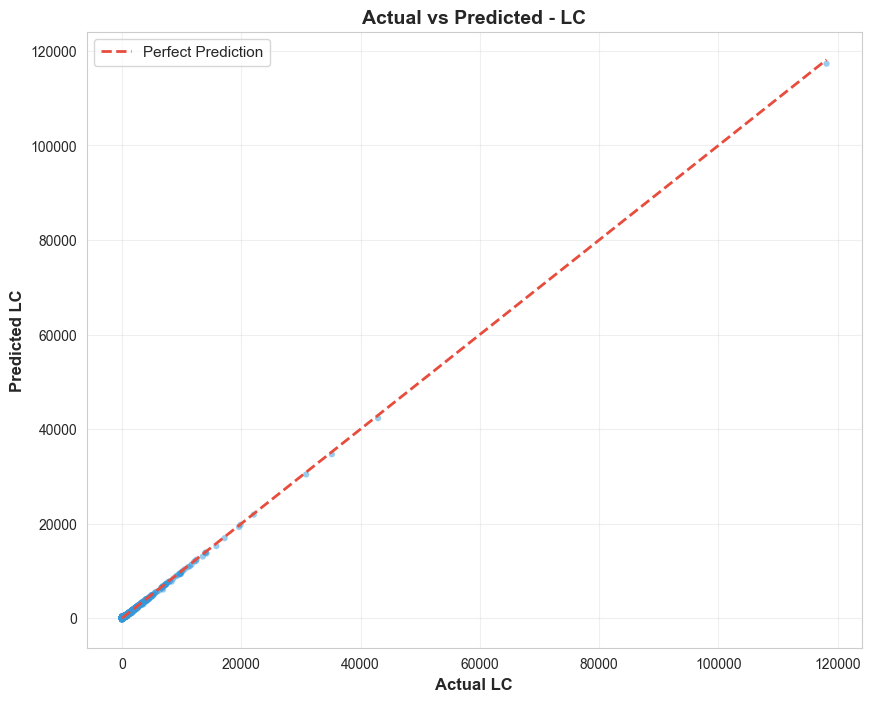

In [10]:
# Visualize actual vs predicted for LC
visualizer = InsuranceVisualizer()
visualizer.plot_actual_vs_predicted(y_lc, lc_pred_train, target_name='LC')

### 7.2 Residual Analysis

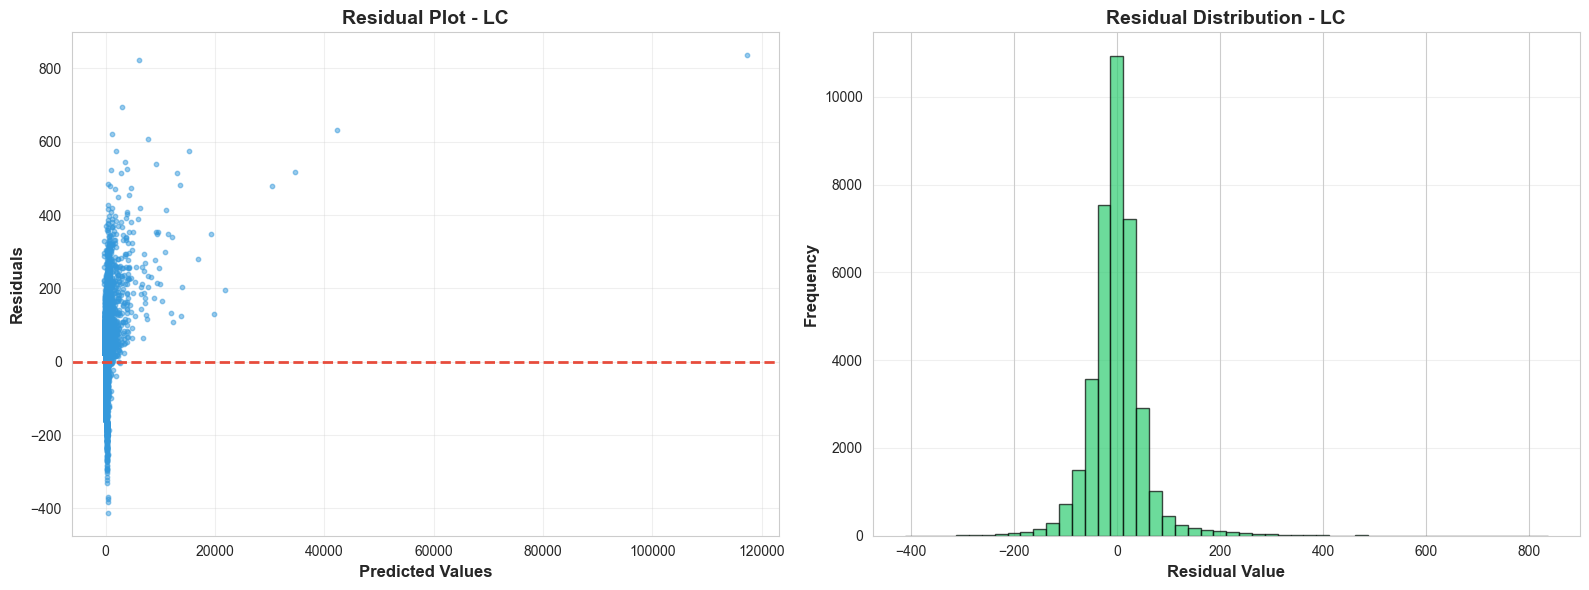

In [11]:
# Plot residuals for LC
visualizer.plot_residuals(y_lc, lc_pred_train, target_name='LC')

### 7.3 Prediction Distribution

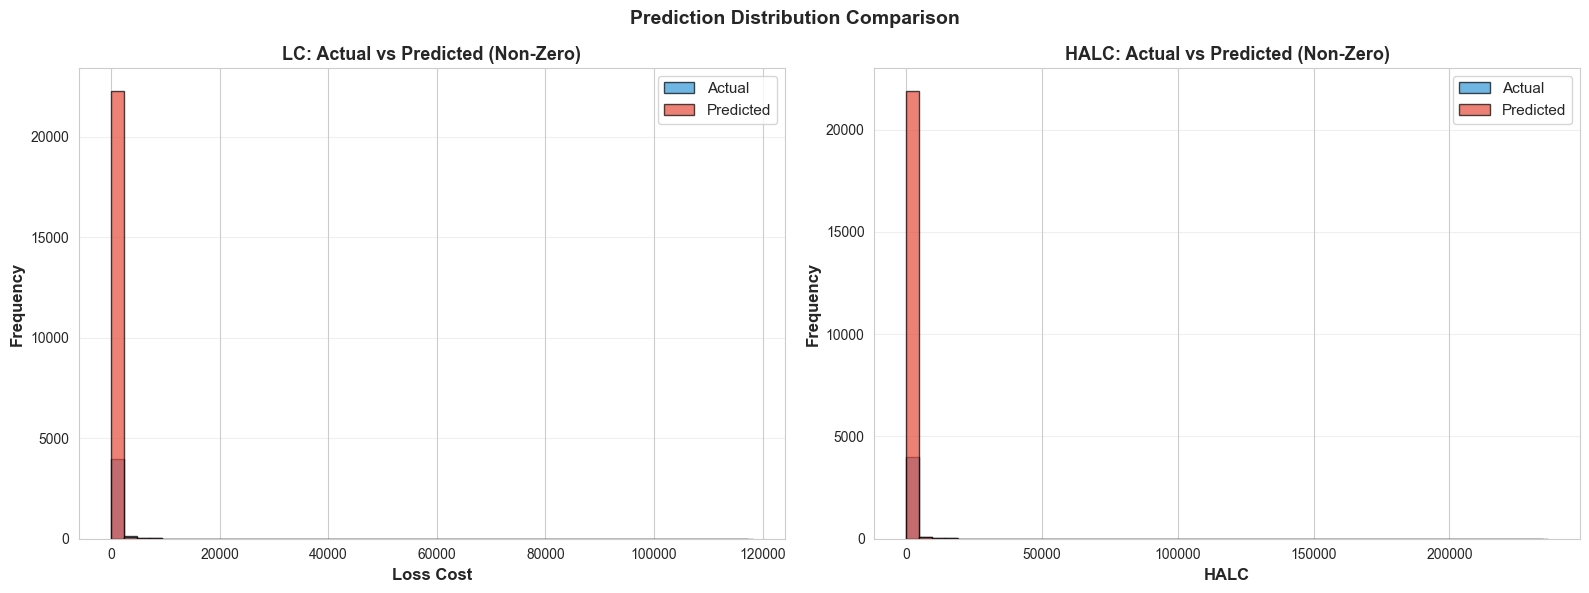

In [12]:
# Compare actual vs predicted distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LC
lc_actual_nonzero = y_lc[y_lc > 0]
lc_pred_nonzero = lc_pred_train[lc_pred_train > 0]

axes[0].hist(lc_actual_nonzero, bins=50, alpha=0.7, label='Actual', 
             color='#3498db', edgecolor='black')
axes[0].hist(lc_pred_nonzero, bins=50, alpha=0.7, label='Predicted', 
             color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Loss Cost', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('LC: Actual vs Predicted (Non-Zero)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# HALC
halc_actual_nonzero = y_halc[y_halc > 0]
halc_pred_nonzero = halc_pred_train[halc_pred_train > 0]

axes[1].hist(halc_actual_nonzero, bins=50, alpha=0.7, label='Actual', 
             color='#3498db', edgecolor='black')
axes[1].hist(halc_pred_nonzero, bins=50, alpha=0.7, label='Predicted', 
             color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('HALC', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('HALC: Actual vs Predicted (Non-Zero)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Prediction Distribution Comparison', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 7.4 Detailed Regression Metrics

In [13]:
# Comprehensive evaluation
evaluator = ModelEvaluator()

lc_metrics = evaluator.evaluate_regressor(y_lc, lc_pred_train, target_name='LC')
halc_metrics = evaluator.evaluate_regressor(y_halc, halc_pred_train, target_name='HALC')

evaluator.print_regression_summary(lc_metrics, "Loss Cost (LC) - Ensemble Results")
evaluator.print_regression_summary(halc_metrics, "HALC - Ensemble Results")


LOSS COST (LC) - ENSEMBLE RESULTS
LC_MSE                   3,024.01
LC_RMSE                     54.99
LC_MAE                      35.18
LC_R2                      0.9957
LC_MAPE                     36.42%

HALC - ENSEMBLE RESULTS
HALC_MSE                 8,762.21
HALC_RMSE                   93.61
HALC_MAE                    59.47
HALC_R2                    0.9968
HALC_MAPE                   48.66%


## 8. Key Takeaways

### Tweedie Advantages:
1. **Natural Zero Handling** - No need for two-stage models
2. **Compound Poisson-Gamma** - Models insurance claims structure
3. **Single-Stage Prediction** - Simpler, more efficient

### Model Performance:
- **Best Single Model**: XGBoost Tweedie (typically lowest MSE)
- **Ensemble**: Weighted combination further improves performance
- **Variance Power**: Optimized via Optuna in range [1.1, 1.9]

### Next Steps:
- Compare Approach A (two-stage) vs Approach B (direct Tweedie) in Notebook 05
- Generate final predictions
- Create submission file